# **Fake and Real News Prediction-NLP Project**

## **Data Understanding**

In [19]:
# Import Libraries
import pandas as pd
import numpy as np
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [20]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# Load Dataset
news_train_data = pd.read_csv('/content/fake_news_train.csv')
news_test_data = pd.read_csv('/content/fake_news_test.csv')

In [22]:
# View data
news_train_data.head()

,text,label
0,Agent every development say. Claim says aliens...,Fake
1,Beautiful instead ahead despite measure ago cu...,Real
2,Everything thank serve civil institution every...,Fake
3,Behavior benefit suggest page. Claim says hidd...,Fake
4,Role movie win. Claim says hidden cities disco...,Fake


In [23]:
# Check values in label of train and test data
print(news_train_data['label'].unique())
print(news_train_data['label'].unique())

['Fake' 'Real']
['Fake' 'Real']


In [24]:
# Binary Encoding
news_train_data['label'] = news_train_data['label'].map({'Fake': 0, 'Real': 1})
news_test_data['label'] = news_test_data['label'].map({'Fake': 0, 'Real': 1})

In [25]:
# After encoding check label values
print(news_train_data['label'].unique())
print(news_test_data['label'].unique())


[0 1]
[0 1]


## **Text Cleaning**

In [26]:
# Text cleaning process
import re
import string
def text_clean(text):
  text = text.lower()
  text = re.sub(r'\[.*?\]', '', text) #remove brackets
  text = re.sub(r'http\S+', '', text) # remove links
  text = re.sub(r'\W', ' ', text) # Remove non-alphnumerics
  text = re.sub(r'\d', '', text) # Remove numbers
  text = text.translate(str.maketrans('', '', string.punctuation)) #Remove punctuation
  text = text.strip() #Remove extra spaces

  words = text.split()
  words = [word for word in words if word not in stop_words]
  return ' '.join(words)

In [27]:
# Apply cleaning(prepare for feature extraction)
news_train_data['text'] = news_train_data['text'].apply(text_clean)
news_test_data['text'] = news_test_data['text'].apply(text_clean)

In [28]:
# Select features and target label
X_train = news_train_data['text']
y_train = news_train_data['label']

X_test = news_test_data['text']
y_test = news_test_data['label']

# check train and test size
print(X_train.shape)
print(X_test.shape)

(5000,)
(1000,)


## **TF-IDF**

For text vectorization (TF-IDF):

* fit() only on training data
* transform() on test data

In [29]:
# Convert text to number using vectorization
vectorizer = TfidfVectorizer(max_df = 0.7,min_df=5,stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

**Description:**

* min_df=5 → Remove rare words (appear less than 5 times)
* stop_words='english' → Automatically remove common English stopwords
* Create a TF-IDF vectorizer that ignores words appearing in more than 70% of documents.

**Example**

Imagine 1000 news articles.

If a word appears in:

* 950 articles → It is useless → Remove it
* 300 articles → Keep it
* 10 articles → Keep it (might be important)

Because 950 / 1000 = 95%
And 95% > 70% → So removed

## **Machine Learning**

In [30]:
# Model selection
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [31]:
# Predict the model
predictions = model.predict(X_test_tfidf)

1.0


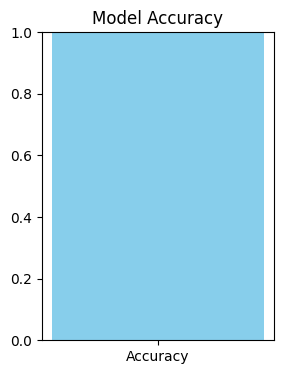

In [32]:
# Evaluation(Accuracy,Confusion matrix, classifcation Report)
# 1. Accuracy
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

# Plot Accuracy
plt.figure(figsize=(3,4))
plt.bar(['Accuracy'],[accuracy], color='Skyblue')
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       506
           1       1.00      1.00      1.00       494

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



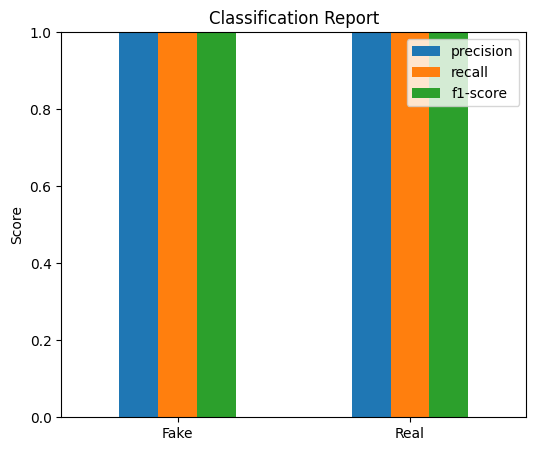

In [33]:
# 2. Classfication Report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

# Plot Classification Report
report = classification_report(y_test, predictions, output_dict=True)#output_dict-gives numeric values instead of string
data_report = pd.DataFrame(report).transpose() # data_report for makes it easier to plot
data_classes = data_report.loc[['0','1'],['precision','recall','f1-score']] #picks only class metrics (ignore support/avg)

data_classes.index = ['Fake','Real'] #makes x-axis readable

data_classes.plot(kind='bar', figsize=(6,5))
plt.title("Classification Report")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.ylim(0,1) #y-axis scaled to 0–1 for readability(Sets y-axis range from 0 to 1)
plt.legend(loc='upper right')
plt.show()

**Classfication Report definition:**

* Precision = TP / (TP + FP) → How many predicted as class X were actually class X
* Recall = TP / (TP + FN) → How many actual class X were correctly predicted
* F1-score = Harmonic mean of precision and recall

Confusion Matrix: [[506   0]
 [  0 494]]


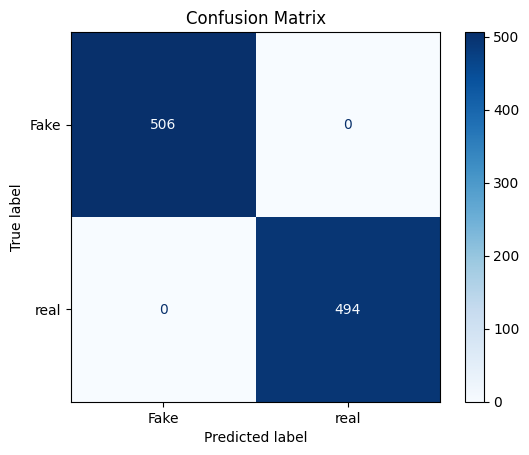

In [34]:
# Confusion matrix
print("Confusion Matrix:",confusion_matrix(y_test,predictions))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,predictions,display_labels = ['Fake','real'],cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**Confusion Matrix:**

1. Row 0 = Actual Fake
    * 500 predicted as Fake (correct)
    * 0 predicted as Real (incorrect)

2. Row 1 = Actual Real
    * 0 predicted as Fake (incorrect)
    * 500 predicted as Real (correct)

**Check Duplicates**

In [35]:
# Check Duplicates
print(sum(X_train.isin(X_test)))

0


**Description:**

X_train.isin(X_test) → checks for each row in X_train if it is also present in X_test

Returns a boolean series (True or False)
sum(...) → counts how many rows are duplicates between training and testing
So the line tells you if any text in the train set is also in the test set.

In machine learning:

* Training data → used to teach the model
* Testing data → used to evaluate the model

If the same rows appear in both, the model has already seen the test samples during training → called data leakage.

>print(sum(X_train.isin(X_test)))  
 Output: 50
Means 50 rows from train are also in test

>Remove duplicates from test
X_test = X_test[~X_test.isin(X_train)]
y_test = y_test[X_test.index]  # align labels